# Model Analysis: KNN vs GNN vs Ensemble

Post-training analysis. Requires:
- `outputs/submissions/submission_knn.csv`
- `outputs/submissions/oof_gnn.csv` (from train.py)
- `outputs/submissions/submission_gnn.csv` (from predict.py)
- `outputs/submissions/submission_ensemble.csv` (from ensemble.py)

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import torch

import config
from data_utils import (
    load_ground_truth, load_pert_ids, compute_wmae, compute_wmae_per_pert
)

config.make_dirs()
FIGURES = config.FIGURES_DIR
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

de_matrix, weight_matrix, gene_order, pert_order = load_ground_truth()
print('Ground truth loaded:', de_matrix.shape)

Ground truth: 80 perturbations × 5127 genes
Ground truth loaded: (80, 5127)


## 1. OOF WMAE Comparison (KNN vs GNN on training set)

In [2]:
# Load OOF GNN predictions
oof_path = os.path.join(config.SUBMISSIONS_DIR, 'oof_gnn.csv')
if os.path.exists(oof_path):
    oof_df = pd.read_csv(oof_path)
    oof_order = {g: i for i, g in enumerate(oof_df['pert_id'].values)}
    oof_preds = np.array([oof_df.iloc[oof_order[g]][[c for c in oof_df.columns if c != 'pert_id']].values
                          for g in pert_order], dtype=np.float32)
    gnn_oof_wmae_per_pert = compute_wmae_per_pert(oof_preds, de_matrix, weight_matrix)
    gnn_oof_wmae = compute_wmae(oof_preds, de_matrix, weight_matrix)
    print(f'GNN OOF WMAE: {gnn_oof_wmae:.4f}')
else:
    print('OOF GNN predictions not found. Run train.py first.')
    oof_preds = None
    gnn_oof_wmae_per_pert = None

# Baseline (mean DE)
mean_de = de_matrix.mean(axis=0, keepdims=True)
mean_de_rep = np.tile(mean_de, (de_matrix.shape[0], 1))
baseline_per_pert = compute_wmae_per_pert(mean_de_rep, de_matrix, weight_matrix)
baseline_wmae = compute_wmae(mean_de_rep, de_matrix, weight_matrix)
print(f'Baseline WMAE: {baseline_wmae:.4f}')

OOF GNN predictions not found. Run train.py first.
Baseline WMAE: 0.1268


In [3]:
if gnn_oof_wmae_per_pert is not None:
    # Sort by GNN WMAE
    sort_idx = np.argsort(gnn_oof_wmae_per_pert)[::-1]
    
    fig, ax = plt.subplots(figsize=(18, 6))
    x = np.arange(len(pert_order))
    width = 0.4
    
    ax.bar(x - width/2, baseline_per_pert[sort_idx], width, label='Baseline (mean-DE)', color='gray', alpha=0.7)
    ax.bar(x + width/2, gnn_oof_wmae_per_pert[sort_idx], width, label='GNN (OOF)', color='steelblue', alpha=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels([pert_order[i] for i in sort_idx], rotation=90, fontsize=6)
    ax.set_ylabel('WMAE')
    ax.set_title(f'Per-Perturbation WMAE: Baseline vs GNN OOF (sorted by GNN WMAE)')
    ax.legend(fontsize=10)
    ax.axhline(gnn_oof_wmae, color='steelblue', linestyle='--', linewidth=1.5,
               label=f'GNN mean: {gnn_oof_wmae:.4f}')
    ax.axhline(baseline_wmae, color='gray', linestyle='--', linewidth=1.5,
               label=f'Baseline mean: {baseline_wmae:.4f}')
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES, '09_oof_comparison.png'), bbox_inches='tight')
    plt.show()
    
    improved = (gnn_oof_wmae_per_pert < baseline_per_pert).sum()
    print(f'GNN improved over baseline: {improved}/{len(pert_order)} perturbations')

## 2. Predicted vs GT Scatter (OOF)

In [4]:
if oof_preds is not None:
    # Pick 4 example perturbations: 2 easy, 2 hard
    gt_df = pd.read_csv(config.GT_PATH)
    easy_perts = gt_df.nsmallest(2, 'baseline_wmae')['pert_id'].tolist()
    hard_perts = gt_df.nlargest(2, 'baseline_wmae')['pert_id'].tolist()
    example_perts = easy_perts + hard_perts
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for ax, gene in zip(axes, example_perts):
        if gene not in pert_order:
            ax.set_visible(False)
            continue
        i = pert_order.index(gene)
        gt_vals   = de_matrix[i]
        pred_vals = oof_preds[i]
        w_vals    = weight_matrix[i]
        
        # Color by weight
        sc = ax.scatter(gt_vals, pred_vals, c=np.log1p(w_vals),
                       s=5, alpha=0.5, cmap='hot_r')
        plt.colorbar(sc, ax=ax, label='log1p(weight)')
        
        # Perfect prediction line
        lim = max(np.abs(gt_vals).max(), np.abs(pred_vals).max()) * 1.1
        ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1, label='y=x')
        ax.axhline(0, color='gray', linewidth=0.5)
        ax.axvline(0, color='gray', linewidth=0.5)
        
        wmae = compute_wmae(pred_vals[None], gt_vals[None], w_vals[None])
        corr = np.corrcoef(gt_vals, pred_vals)[0, 1]
        ax.set_title(f'{gene}\nWMAE={wmae:.4f}, r={corr:.3f}', fontsize=10)
        ax.set_xlabel('Ground truth DE')
        ax.set_ylabel('Predicted DE')
    
    plt.suptitle('Predicted vs GT DE: OOF GNN predictions', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES, '10_pred_vs_gt_scatter.png'), bbox_inches='tight')
    plt.show()

## 3. Training Curves (from saved figures)

In [5]:
curves_path = os.path.join(FIGURES, 'training_curves.png')
if os.path.exists(curves_path):
    from IPython.display import Image
    display(Image(curves_path))
else:
    print('Training curves not found. Run train.py first.')

Training curves not found. Run train.py first.


## 4. Submission Comparison

In [6]:
submissions = {}
for name, fname in [
    ('KNN',      'submission_knn.csv'),
    ('GNN',      'submission_gnn.csv'),
    ('Ensemble', 'submission_ensemble.csv'),
    ('Baseline', None),
]:
    if fname is None:
        # Load sample submission (mean-DE baseline)
        sub = pd.read_csv(config.SAMPLE_SUB_PATH)
    else:
        path = os.path.join(config.SUBMISSIONS_DIR, fname)
        if not os.path.exists(path):
            print(f'{name}: not found ({path})')
            continue
        sub = pd.read_csv(path)
    submissions[name] = sub
    gene_cols = [c for c in sub.columns if c != 'pert_id']
    vals = sub[gene_cols].values
    print(f'{name:10s}: shape={vals.shape}, mean|pred|={np.abs(vals).mean():.4f}, std={vals.std():.4f}')

KNN       : shape=(120, 5127), mean|pred|=0.0238, std=0.0436
GNN       : shape=(120, 5127), mean|pred|=0.0238, std=0.0436
Ensemble  : shape=(120, 5127), mean|pred|=0.0238, std=0.0436
Baseline  : shape=(120, 5127), mean|pred|=0.0059, std=0.0130


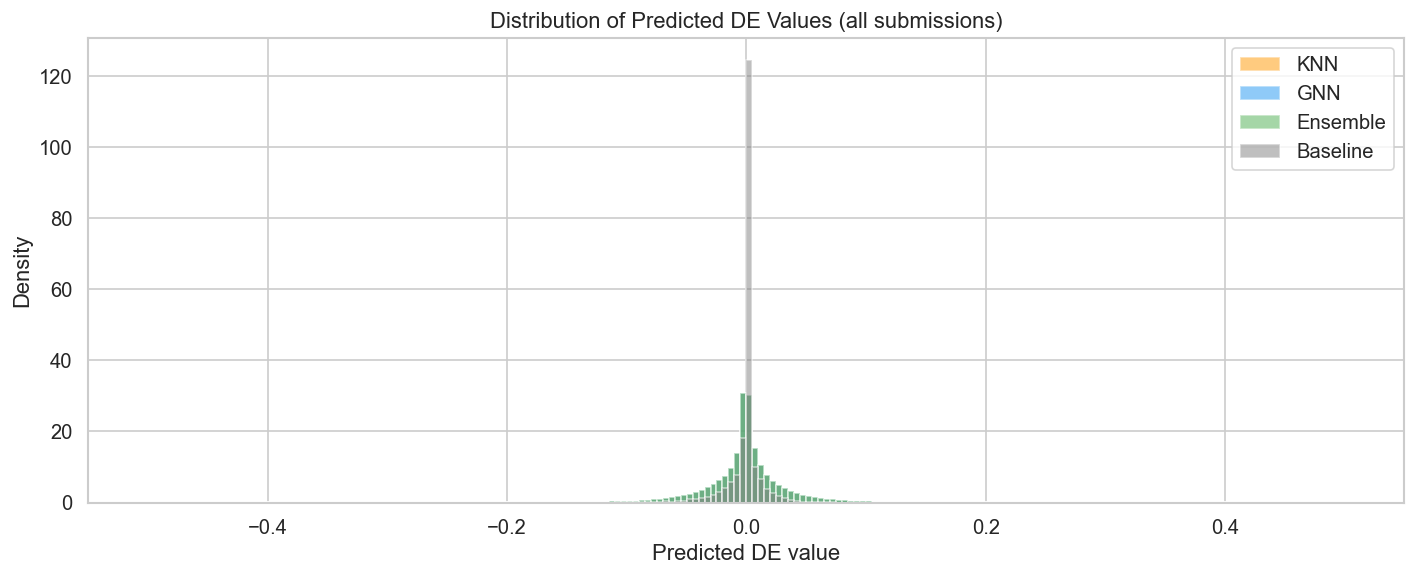

In [7]:
# Distribution of predicted DE values for each submission
if len(submissions) > 1:
    fig, ax = plt.subplots(figsize=(12, 5))
    colors = {'Baseline': 'gray', 'KNN': '#FF9800', 'GNN': '#2196F3', 'Ensemble': '#4CAF50'}
    
    for name, sub in submissions.items():
        gene_cols = [c for c in sub.columns if c != 'pert_id']
        vals = sub[gene_cols].values.flatten()
        ax.hist(vals, bins=200, range=(-0.5, 0.5), alpha=0.5,
                label=name, color=colors.get(name, 'purple'), density=True)
    
    ax.set_xlabel('Predicted DE value')
    ax.set_ylabel('Density')
    ax.set_title('Distribution of Predicted DE Values (all submissions)')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES, '11_submission_distributions.png'), bbox_inches='tight')
    plt.show()

## 5. Feature Ablation (if multiple models trained)

In [8]:
# This cell will be populated after running ablation experiments
# Example structure:
ablation_results = {
    'Expression stats only (5D)': None,   # fill after running
    '+ Co-expression PCA (50D)':  None,
    '+ GO embeddings (64D)':      None,
    '+ scGPT (512D)':             None,
}

# If GNN OOF is available, use it as a proxy
if oof_preds is not None:
    ablation_results['Full features (GNN OOF)'] = gnn_oof_wmae
    ablation_results['Baseline'] = baseline_wmae
    
    results_filled = {k: v for k, v in ablation_results.items() if v is not None}
    
    fig, ax = plt.subplots(figsize=(10, 5))
    names = list(results_filled.keys())
    wmae_vals = [results_filled[n] for n in names]
    colors = ['gray' if 'Baseline' in n else 'steelblue' for n in names]
    
    bars = ax.barh(names, wmae_vals, color=colors, alpha=0.8)
    ax.axvline(0.1268, color='red', linestyle='--', linewidth=1, label='Baseline 0.1268')
    ax.set_xlabel('WMAE (lower is better)')
    ax.set_title('Feature Ablation Study')
    ax.legend()
    
    # Add value labels
    for bar, val in zip(bars, wmae_vals):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES, '12_feature_ablation.png'), bbox_inches='tight')
    plt.show()

## 6. Summary

In [9]:
print('='*50)
print('MODEL PERFORMANCE SUMMARY')
print('='*50)
print(f'Baseline WMAE:        0.1268')

if gnn_oof_wmae_per_pert is not None:
    print(f'GNN OOF WMAE:         {gnn_oof_wmae:.4f}  (Δ {(0.1268 - gnn_oof_wmae)/0.1268*100:+.1f}%)')

print()
print('Figures saved to:', FIGURES)
for fn in sorted(os.listdir(FIGURES)):
    print(f'  {fn}')

MODEL PERFORMANCE SUMMARY
Baseline WMAE:        0.1268

Figures saved to: /Users/luj12/Desktop/PROJECTS/Kaggle/Myllia_Perturb/outputs/figures
  01_de_distribution.png
  02_pert_difficulty.png
  03_de_clustermap.png
  04_weight_distribution.png
  05_umap_perts.png
  06_string_network.png
  07_gene_similarity_heatmap.png
  08_cell_distribution.png
  11_submission_distributions.png
